## Run GEAGS Model - for ssrA tagged sfYFP data
This files runs the two CRN models created in `Build_GEAGS_model.ipynb`. Both models (with and without degradation tag) are stored as SBML files under `SBML_model_files`. <br> <br>To simulate the SBML files, we use the Bioscrape simulator, which is a fast Cython-based simulator. 
 <br> <br> To run the models, we load a parameter file that uses LMFIT objects to specify the bounds on the parameters. The parameters can be exported for parameter estimation using LMFIT.

In [1]:
## Import all the packages in this cell

from biocrnpyler import *
from bioscrape.types import Model
from bioscrape.simulator import py_simulate_model

import pandas as pd
import numpy as np
import lmfit 

from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D

from matplotlib import style
%config InlineBackend.figure_format = 'retina'

style.use("default")

%matplotlib inline

# To import experimental data 

from experiment_data.expt_data_import import *

In [2]:
## Load the model and defining the timepoints

model_degtag = Model(sbml_filename = 'SBML_model_files/Biocrnpyler_model_degtag_080425.xml')
model_no_tag = Model(sbml_filename = 'SBML_model_files/Biocrnpyler_model_no_degtag_080425.xml')

N_steps = 720
#N_steps = 720*40 # For simulation run for sensitivity analysis
t_final = 720
timepoints = np.linspace(0, t_final, N_steps)

tf_I = 720*40  # Time till we want to plot the simulation 
tf_i = 72   # Indice of the experimental data array till we want to plot the simulation

In [3]:
# Loading the experimental data 

[C, C_max, C_0, k_gr, C_max_avg, C_0_avg, k_gr_avg] = Get_OD_Data()
[A_non_leaky, time_A, B_non_leaky, time_B, avg_fold_change] = Get_FLOD_Data()

# A_non_leaky[0] = A_non_leaky[0] * 0

In [4]:
A1 = A_non_leaky[0] 
A2 = A_non_leaky[1]
A3 = A_non_leaky[2]
A4 = A_non_leaky[3]
A_avg = np.mean((A1, A2,A3, A4), axis = 0)
A_max = np.max(A_avg)

In [5]:
## Wrote a function to pass the parameters of the model 

def run_CRN_model(param, model_degtag, model_no_tag, timepoints): 

    params = param.valuesdict() # params is an LMFIT object so values of parameters are extracted as a dictinory 

    n = 5.5 # Fixed parameter

    model_degtag.set_species({'dna_sfYFP': 100,
    'protein_sigma_machinery': params['Sigma_IC'],
    'protein_NT_nucleotide': params['NT_IC'],
    'protein_AA_aminoacid': params['AA_IC'],
    'protein_RNAase_machinery': params['RNAase_IC'],
    'protein_unfolded_protein_degtag': 0,
    'rna_T_sfYFP':0,
    'protein_sfYFP':0,
    'cell_count_count': C_0_avg})

    model_no_tag.set_species({'dna_sfYFP': 100,
    'protein_sigma_machinery': params['Sigma_IC'],
    'protein_NT_nucleotide': params['NT_IC'],
    'protein_AA_aminoacid': params['AA_IC'],
    'protein_RNAase_machinery': params['RNAase_IC'],
    'protein_unfolded_protein_degtag': 0,
    'rna_T_sfYFP':0,
    'protein_sfYFP':0,
    'cell_count_count': C_0_avg})

    model_degtag.set_params({'k__logistic_cell_growth': params['k_gr'], 
    'c_max__logistic_cell_growth': params['C_max'],
    'RNAP_max__bacterial_transcription': params['RNAP_max'],
    'n_gamma_RNAP__bacterial_transcription' : params['n_gamma_RNAP'],
    'Et_max__bacterial_translation': params['Et_max'],
    'n_gamma_Et__bacterial_translation' : params['n_gamma_Et'],
    'Ribo_max__bacterial_translation': params['Ribo_max'],
    'n_gamma_Ribo__bacterial_translation' : params['n_gamma_Ribo'],
    'tRNA_max__bacterial_translation': params['tRNA_max'],
    'n_gamma_tRNA__bacterial_translation' : params['n_gamma_tRNA'],
    'Protease_max__bacterial_translation': params['Protease_max'],
    'n_gamma_Protease__bacterial_translation' : params['n_gamma_Protease'],
    'n_gamma_folding__bacterial_translation' : params['n_gamma_folding'],
    'n_gamma_syn__bacterial_translation' : params['n_gamma_syn'],
   

    'k_tx_1b__bacterial_transcription':params['k_tx_1b'],
    'k_tx_1u__bacterial_transcription':params['k_tx_1u'],
    'k_tx_2u__bacterial_transcription':params['k_tx_2u'],
    'k_tx_2b__bacterial_transcription':params['k_tx_2b'],
    'k_tx_3__bacterial_transcription': params['k_tx_3'],
    'k_tx_4b__mrna_degradation':params['k_tx_4b'],
    'k_tx_4u__mrna_degradation':params['k_tx_4u'],
    'k_tx_5__mrna_degradation': params['k_tx_5'],

    'k_tl_1b__bacterial_translation':params['k_tl_1b'],
    'k_tl_1u__bacterial_translation':params['k_tl_1u'],
    'k_tl_2b__bacterial_translation':params['k_tl_2b'],
    'k_tl_3u__bacterial_translation':params['k_tl_3u'],
    'k_tl_3b__bacterial_translation':params['k_tl_3b'],
    'k_tl_4__bacterial_translation':params['k_tl_4'],
    'k_tl_5__bacterial_translation':params['k_tl_5'],
    'b_tl_5__bacterial_translation':params['b_tl_5'],
    'k_tl_6__bacterial_translation':params['k_tl_6'],
    'k_tl_7__non_tag_degradation':params['k_tl_7'],
    'k_tl_8__bacterial_translation':params['k_tl_8'],
    'k_tl_9b_P__bacterial_translation': params['k_tl_9b_P'],
    'k_tl_9b_Pm__bacterial_translation': params['k_tl_9b_Pm'],
    'k_tl_9u__bacterial_translation': params['k_tl_9u'],
    'k_tl_10__bacterial_translation': params['k_tl_10'],

    'n_delta__bacterial_transcription': n, 
    'n_delta__non_tag_degradation': n, 
    'n_delta__mrna_degradation': n})

    model_no_tag.set_params({'k__logistic_cell_growth': params['k_gr'], 
    'c_max__logistic_cell_growth': params['C_max'],
    'RNAP_max__bacterial_transcription': params['RNAP_max'],
    'n_gamma_RNAP__bacterial_transcription' : params['n_gamma_RNAP'],
    'Et_max__bacterial_translation': params['Et_max'],
    'n_gamma_Et__bacterial_translation' : params['n_gamma_Et'],
    'Ribo_max__bacterial_translation': params['Ribo_max'],
    'n_gamma_Ribo__bacterial_translation' : params['n_gamma_Ribo'],
    'tRNA_max__bacterial_translation': params['tRNA_max'],
    'n_gamma_tRNA__bacterial_translation' : params['n_gamma_tRNA'],
    'n_gamma_folding__bacterial_translation' : params['n_gamma_folding'],
    'n_gamma_syn__bacterial_translation' : params['n_gamma_syn'],
   

    'k_tx_1b__bacterial_transcription':params['k_tx_1b'],
    'k_tx_1u__bacterial_transcription':params['k_tx_1u'],
    'k_tx_2u__bacterial_transcription':params['k_tx_2u'],
    'k_tx_2b__bacterial_transcription':params['k_tx_2b'],
    'k_tx_3__bacterial_transcription': params['k_tx_3'],
    'k_tx_4b__mrna_degradation':params['k_tx_4b'],
    'k_tx_4u__mrna_degradation':params['k_tx_4u'],
    'k_tx_5__mrna_degradation': params['k_tx_5'],

    'k_tl_1b__bacterial_translation':params['k_tl_1b'],
    'k_tl_1u__bacterial_translation':params['k_tl_1u'],
    'k_tl_2b__bacterial_translation':params['k_tl_2b'],
    'k_tl_3u__bacterial_translation':params['k_tl_3u'],
    'k_tl_3b__bacterial_translation':params['k_tl_3b'],
    'k_tl_4__bacterial_translation':params['k_tl_4'],
    'k_tl_5__bacterial_translation':params['k_tl_5'],
    'b_tl_5__bacterial_translation':params['b_tl_5'],
    'k_tl_7__non_tag_degradation':params['k_tl_7'],
    'k_tl_8__bacterial_translation':params['k_tl_8'],
    'k_tl_10__bacterial_translation': params['k_tl_10'],

    'n_delta__bacterial_transcription': n, 
    'n_delta__non_tag_degradation': n, 
    'n_delta__mrna_degradation': n})

    sol_deg = py_simulate_model(timepoints = timepoints, Model = model_degtag)
    sol_no_deg = py_simulate_model(timepoints = timepoints, Model = model_no_tag)

    return sol_deg, sol_no_deg

In [6]:
## LMFIT object is used to define the parameters 

params = lmfit.Parameters()
# Loading a parameter file 
# p = pd.read_csv('Parameter Estimation/model_param_file_080425.csv').to_numpy() # parameter file used for sfYFP-aav
p = pd.read_csv('Parameter Estimation/params_best_fit_091725_only_deg_params.csv').to_numpy() # parameter file used for sfYFP-ssrA
p = p[:,2]


params.add(name = 'n_gamma_RNAP', value = p[0], min = 0.01, max = 0.9, vary = 1)
params.add(name = 'n_gamma_Et', value = p[1], min = 0.01, max = 0.9, vary = 1)
params.add(name = 'n_gamma_tRNA', value = p[2]*1 , min = 0.01, max = 0.9, vary = 1)
params.add(name = 'n_gamma_Ribo', value = p[3]*1, min = 0.01, max = 0.9, vary = 1)
params.add(name = 'n_gamma_Protease', value = p[4]*1, min = 0.01, max = 0.9, vary = 1)

params.add(name = "Sigma_IC", value = p[5], min = 1e1, max = 1e4, vary = 1)
params.add(name = "NT_IC", value = p[6]*1, min = 1e1, max = 1e4, vary = 1)
params.add(name = "RNAase_IC", value = p[7]*1, min = 1e1, max = 1e4, vary = 1)
params.add(name = "AA_IC", value = p[8]*1, min = 1e1, max = 1e6, vary = 1)

params.add(name = "Ribo_max", value = p[9]*1, min = 1e1, max = 1e4, vary = 1)
params.add(name = "tRNA_max", value = p[10]*1, min = 1e1, max = 1e4, vary = 1)
params.add(name = "RNAP_max", value = p[11]*1, min = 1e1, max = 1e4, vary = 1)
params.add(name = "Et_max", value = p[12]*1, min = 1e1, max = 1e4, vary = 1)
params.add(name = "Protease_max", value = p[13]*1, min = 1e1, max = 1e4, vary = 1)

k_tx_1b = 0.0371*1
k_tx_2u = 0.097*2

params.add(name = 'k_tx_1b', value = p[14]*1, min = 1*1e-3, max = 1*1e-1, vary = 1)
params.add(name = 'k_tx_1u', value = p[15], min = 3.71, max = 37.1, vary = 1)
params.add(name = 'k_tx_2b', value = p[16]*1 , min = 1.94e-4, max = 1.94e-3, vary = 1)
params.add(name = 'k_tx_2u', value = p[17]*1, min = 0.01, max = 0.1, vary = 1)
params.add(name = 'k_tx_3', value = p[18]*1, min = 0.001, max = 0.0036, vary = 1)
params.add(name = 'k_tx_4b', value = p[19], min = 0.1, max = 5, vary = 1)
params.add(name = 'k_tx_4u', value = p[20]*1, min = 100, max = 200, vary = 1)
params.add(name = 'k_tx_5', value = p[21]*1, min = 0.1, max = 10, vary = 1)

params.add(name = 'k_tl_1b', value = p[22], min = 1e-3, max = 1e1, vary = 1)
params.add(name = 'k_tl_1u', value = p[23], min = 1e1, max = 1e4, vary = 1)
params.add(name = 'k_tl_2u', value = p[24],  min = 1e1, max = 1e4, vary = 1)
params.add(name = 'k_tl_2b', value = p[25], min = 1e-3, max = 1e1, vary = 1)
params.add(name = 'k_tl_3b', value = p[26]*1,  min = 1e-3, max = 1e0, vary = 1)
params.add(name = 'k_tl_3u', value = p[27]*1, min = 1e1, max = 1e4, vary = 1)
params.add(name = 'k_tl_4', value = p[28]*1, min = 0.05, max = 1, vary = 1)
params.add(name = 'k_tl_5', value = p[29]*1, min = 0.1, max = 0.3, vary = 1)
params.add(name = "b_tl_5", value = p[30]*1, min = 0, max = 1, vary = 1)
params.add(name = 'k_tl_6', value = p[31]*1, min = 0.01, max = 10, vary = 1)
params.add(name = 'k_tl_7', value = p[32]*1, min = 0.0005, max = 0.01, vary = 1)
params.add(name = 'k_tl_8', value = p[33]*1, min = 1e1, max = 1e4, vary = 1)
params.add(name = 'k_tl_9b_P', value = p[34]*1, min = 1e-4, max = 1e1, vary = 1)
params.add(name = 'k_tl_9b_Pm', value = p[35]*1, min = 1e-4, max = 1e1, vary = 1)
params.add(name = 'k_tl_9u', value = p[36]*1, min = 1e1, max = 1e4, vary = 1)
params.add(name = 'k_tl_10', value = p[37]*1, min = 1e-4, max = 1e0, vary = 1)
params.add(name = 'n_gamma_folding', value = p[38]*1, min = 0.01, max = 0.9, vary = 1)
params.add(name = 'n_gamma_syn', value = p[39]*1, min = 0.01, max = 0.9, vary = 1)

params.add(name = 'C_max', value = C_max_avg, vary = 0)
params.add(name = "C_0", value = p[41], vary = 0)
params.add(name = "k_gr", value = k_gr_avg*0.975, vary = 0)


sol_deg, sol_no_deg = run_CRN_model(params, model_degtag, model_no_tag, timepoints)


## Plotting results

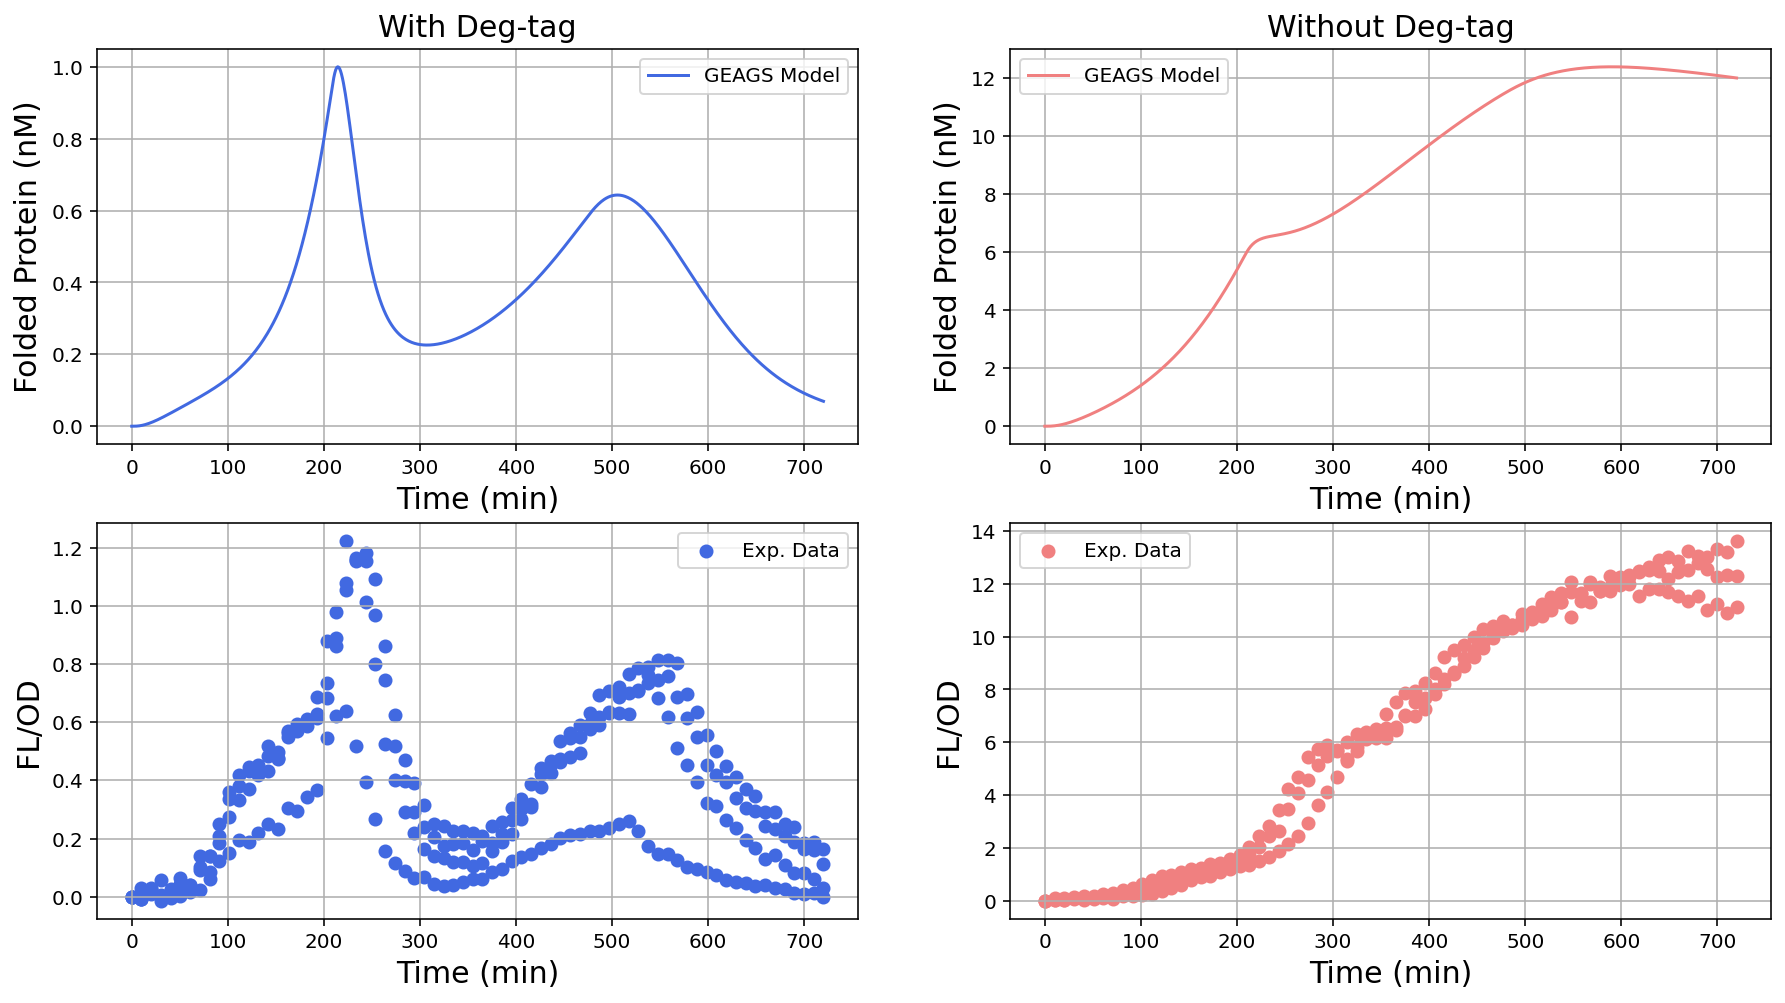

In [7]:
fig, ax = plt.subplots(2,2, figsize = (15,8))
fig.subplots_adjust(wspace = 0.2)#, hspace = 0.1)

last_ind = -1
r,c = 0,0
ax[r,c].plot(timepoints[:tf_I], sol_deg['protein_sfYFP'][:tf_I]/np.max(sol_deg['protein_sfYFP']), label = "GEAGS Model", color = 'royalblue')
ax[r,c].set_xlabel('Time (min)', fontsize = 15) ; ax[r,c].set_ylabel('Folded Protein (nM)', fontsize = 15) 
ax[r,c].set_title('With Deg-tag', fontsize = 15) ; ax[r,c].grid(True) ; ax[r,c].legend()

r,c = 0,1
ax[r,c].plot(timepoints[:tf_I], sol_no_deg['protein_sfYFP'][:tf_I]/np.max(sol_deg['protein_sfYFP']), label = "GEAGS Model", color = 'lightcoral')
ax[r,c].set_xlabel('Time (min)', fontsize = 15) ; ax[r,c].set_ylabel('Folded Protein (nM)', fontsize = 15) 
ax[r,c].set_title('Without Deg-tag', fontsize = 15) ; ax[r,c].grid(True) ; ax[r,c].legend()

r,c = 1,0
ax[r,c].scatter(time_A[0][:tf_i], A_non_leaky[0][:tf_i]/A_max, color = 'royalblue', label = 'Exp. Data')
ax[r,c].scatter(time_A[1][:tf_i], A_non_leaky[1][:tf_i]/A_max, color = 'royalblue')
ax[r,c].scatter(time_A[2][:tf_i], A_non_leaky[2][:tf_i]/A_max, color = 'royalblue')
ax[r,c].scatter(time_A[3][:tf_i], A_non_leaky[3][:tf_i]/A_max, color = 'royalblue')
ax[r,c].set_xlabel('Time (min)', fontsize = 15) ; ax[r,c].set_ylabel('FL/OD', fontsize = 15) ; ax[r,c].legend()
#ax[r,c].set_title('With Deg-tag') ; 
ax[r,c].grid(True)

r,c = 1,1
ax[r,c].scatter(time_B[0][:tf_i], B_non_leaky[0][:tf_i]/A_max, color = 'lightcoral', label = 'Exp. Data')
ax[r,c].scatter(time_B[1][:tf_i], B_non_leaky[1][:tf_i]/A_max, color = 'lightcoral')
ax[r,c].scatter(time_B[2][:tf_i], B_non_leaky[2][:tf_i]/A_max, color = 'lightcoral')
ax[r,c].set_xlabel('Time (min)', fontsize = 15) ; ax[r,c].set_ylabel('FL/OD', fontsize = 15) ; ax[r,c].legend()
#ax[r,c].set_title('Without Deg-tag') ; 
ax[r,c].grid(True)

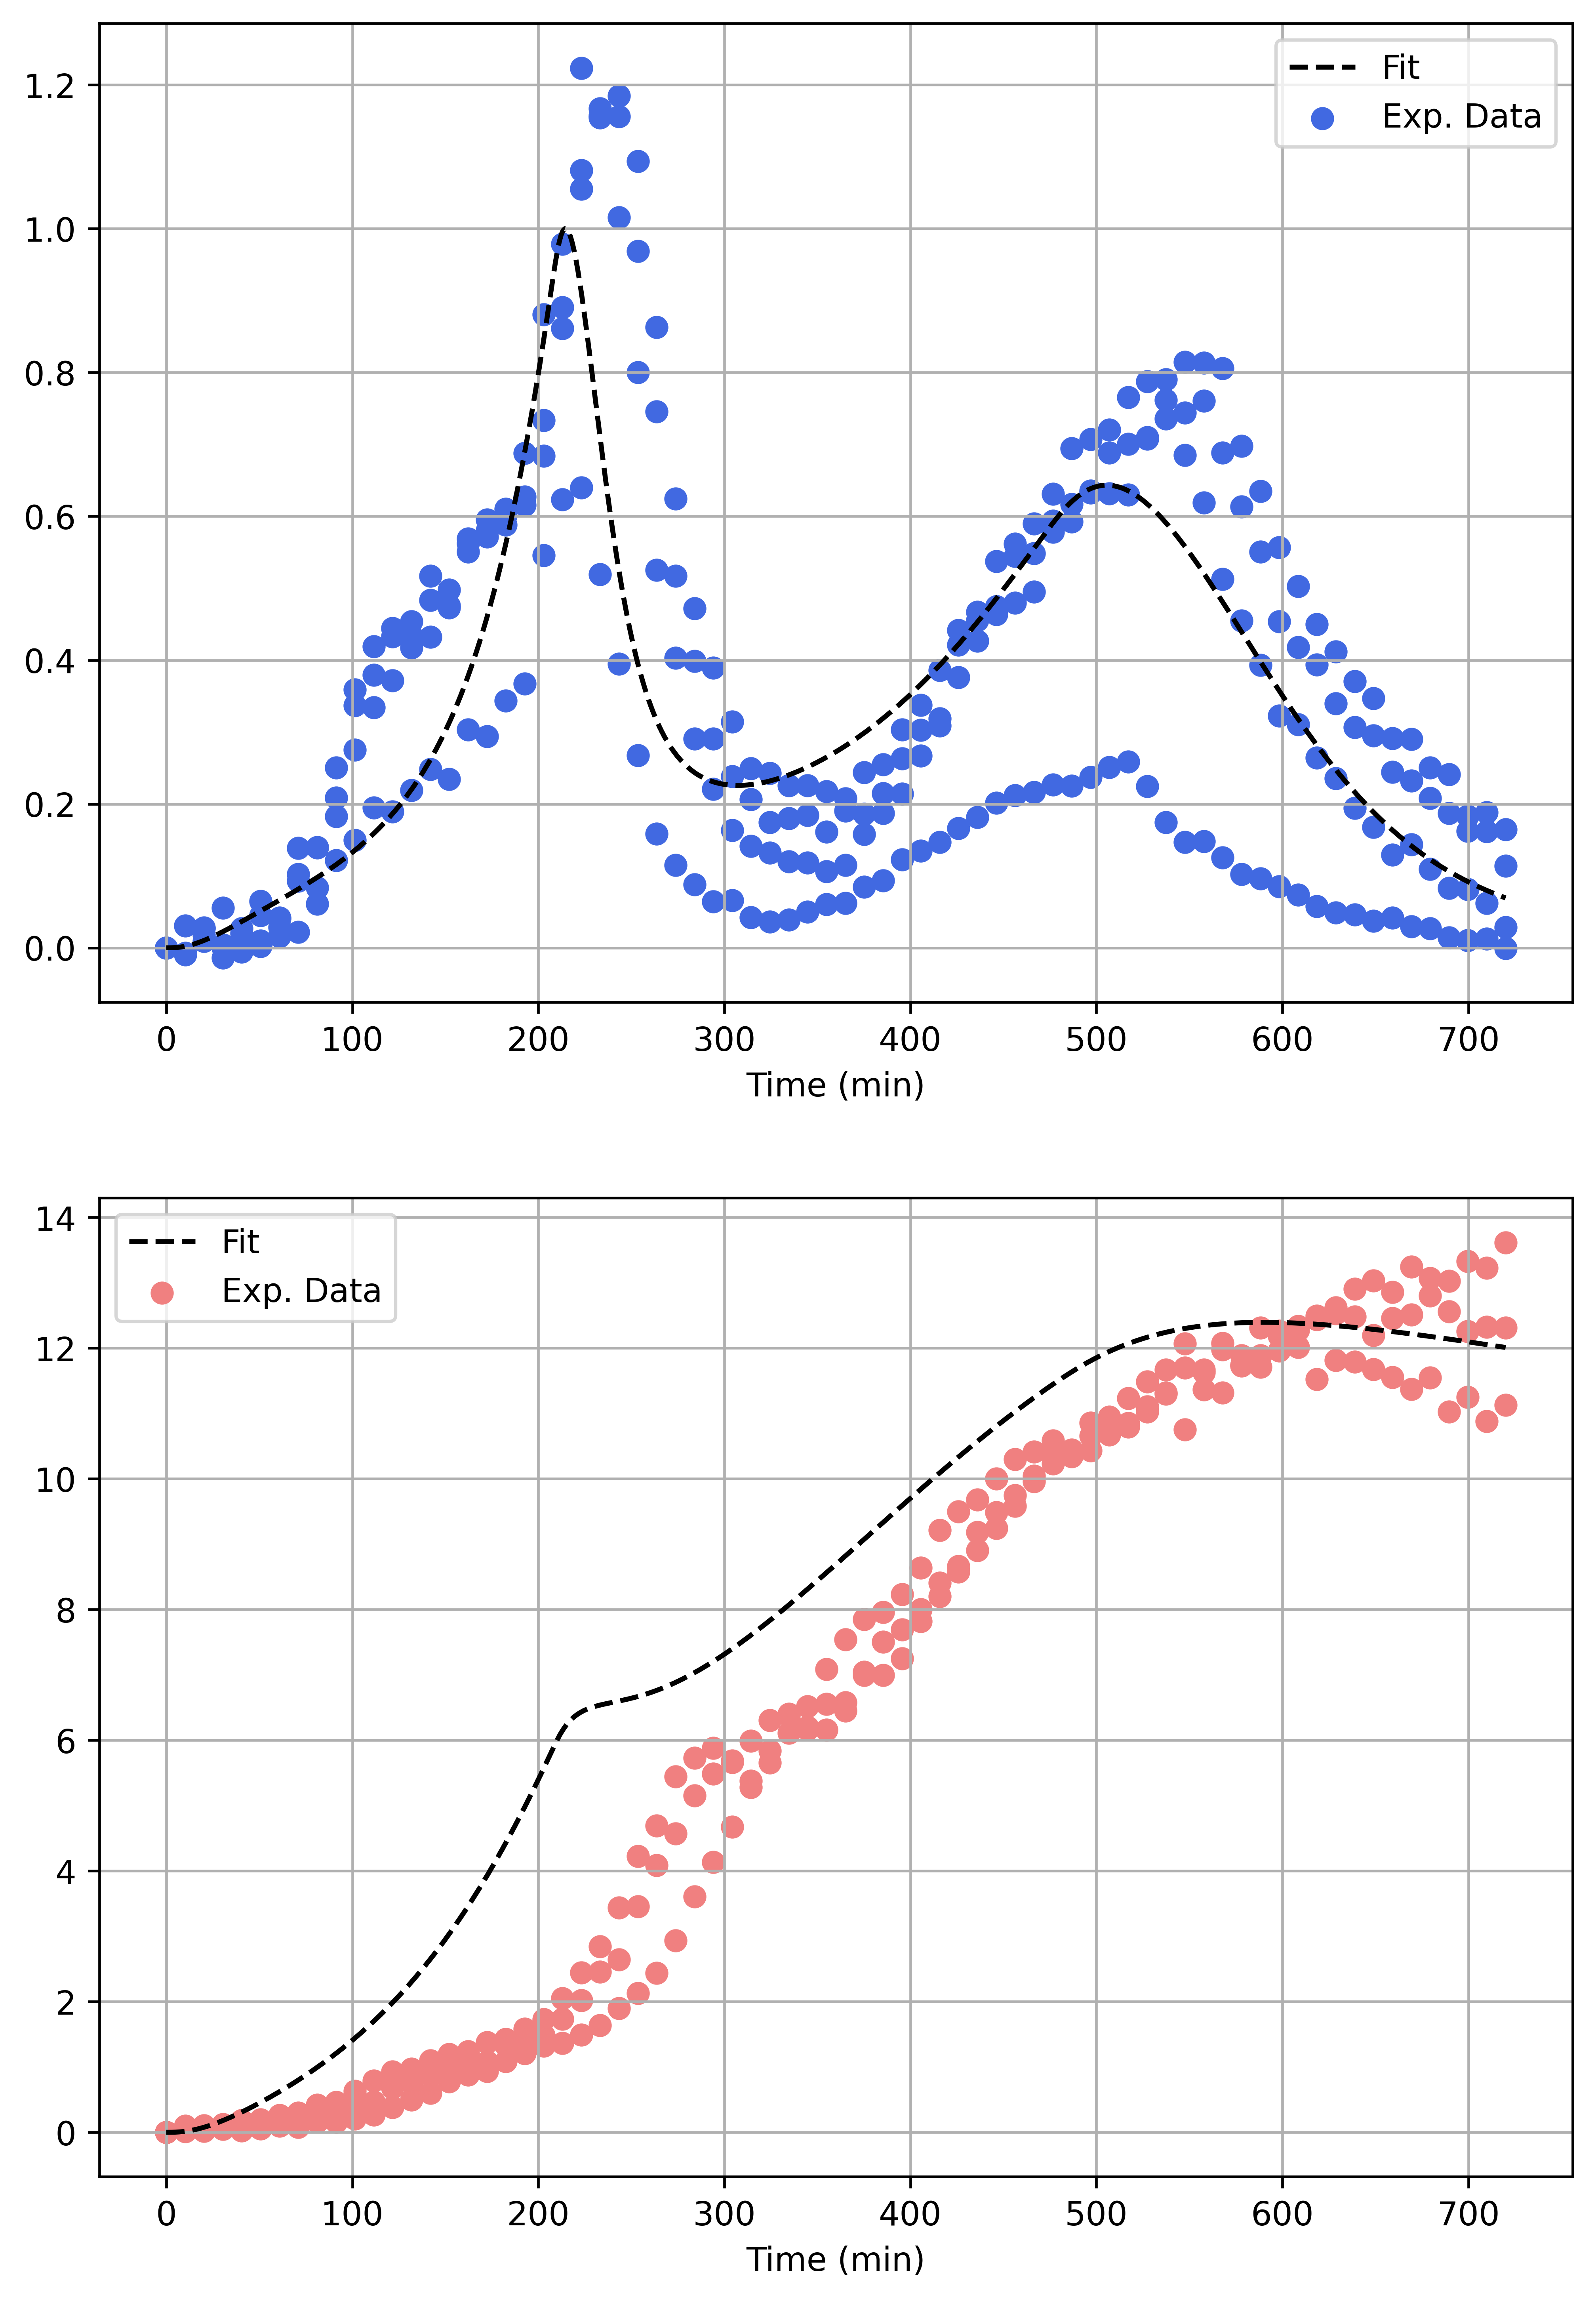

In [8]:
#fig, ax = plt.subplots(1,2, figsize = (15,5))
fig, ax = plt.subplots(2,1, figsize = (8,12), dpi = 300)


ax[0].plot(timepoints[:tf_I], sol_deg['protein_sfYFP'][:tf_I]/np.max(sol_deg['protein_sfYFP']), '--', label = "Fit", color = 'black')
ax[0].scatter(time_A[0][:tf_i], A_non_leaky[0][:tf_i]/A_max, color = 'royalblue', label = 'Exp. Data')
ax[0].scatter(time_A[1][:tf_i], A_non_leaky[1][:tf_i]/A_max, color = 'royalblue')
ax[0].scatter(time_A[2][:tf_i], A_non_leaky[2][:tf_i]/A_max, color = 'royalblue')
ax[0].scatter(time_A[3][:tf_i], A_non_leaky[3][:tf_i]/A_max, color = 'royalblue')
ax[0].set_xlabel('Time (min)'); ax[0].grid(True) ; ax[0].legend()


ax[1].plot(timepoints[:tf_I], sol_no_deg['protein_sfYFP'][:tf_I]/np.max(sol_deg['protein_sfYFP']), '--', label = "Fit", color = 'black')
ax[1].scatter(time_B[0][:tf_i], B_non_leaky[0][:tf_i]/A_max, color = 'lightcoral', label = 'Exp. Data')
ax[1].scatter(time_B[1][:tf_i], B_non_leaky[1][:tf_i]/A_max, color = 'lightcoral')
ax[1].scatter(time_B[2][:tf_i], B_non_leaky[2][:tf_i]/A_max, color = 'lightcoral')
ax[1].set_xlabel('Time (min)'); ax[1].grid(True) ; ax[1].legend()

#fig.savefig("GEAGS_qualitative_comparison.png")

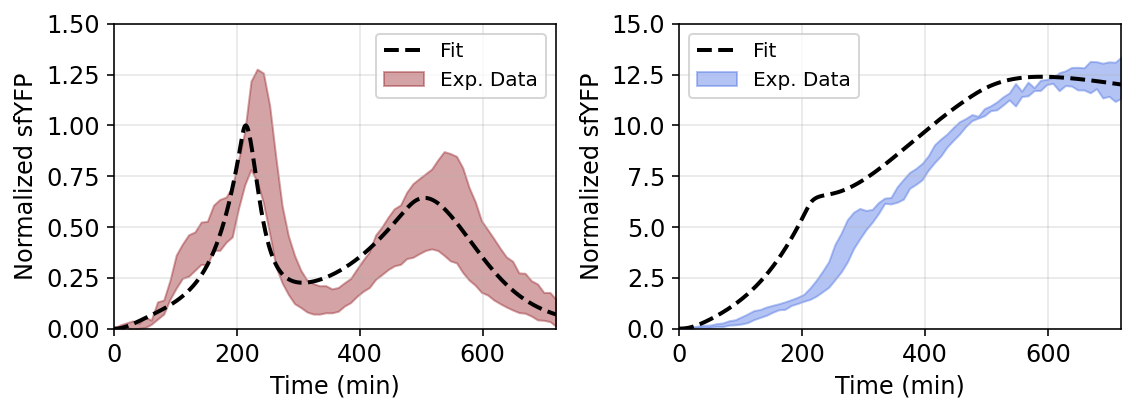

In [9]:
# Publication grade image

# ===============================
# User-controlled style parameters
# ===============================
figsize = (8, 3)         # Figure size (width, height)
label_fontsize = 12       # Axis label fontsize
tick_fontsize = 12        # Tick label fontsize
legend_fontsize = 10      # Legend fontsize
linewidth = 2             # Line thickness
alpha_fill = 0.4          # Transparency of shaded region
grid_alpha = 0.3          # Transparency of gridlines

# ===============================
# Compute means, stds, and bounds
# ===============================
mean_exp_A = np.mean(A_non_leaky, axis=0)[:,0]/A_max
std_exp_A  = np.std(A_non_leaky, axis=0)[:,0]/A_max
upper_A, lower_A = mean_exp_A + std_exp_A, mean_exp_A - std_exp_A

mean_exp_B = np.mean(B_non_leaky, axis=0)[:,0]/A_max
std_exp_B  = np.std(B_non_leaky, axis=0)[:,0]/A_max
upper_B, lower_B = mean_exp_B + std_exp_B, mean_exp_B - std_exp_B

# ===============================
# Plotting
# ===============================
fig, ax = plt.subplots(1, 2, figsize=figsize)

# --- Panel A ---
ax[0].plot(
    timepoints[:tf_I],
    sol_deg['protein_sfYFP'][:tf_I] / np.max(sol_deg['protein_sfYFP']),
    '--', label="Fit", color='black', linewidth=linewidth
)
ax[0].fill_between(
    time_A[0][:tf_i], upper_A, lower_A,
    color='#931a20', alpha=alpha_fill, label='Exp. Data'
)
ax[0].set_xlabel('Time (min)', fontsize=label_fontsize)
ax[0].set_ylabel('Normalized sfYFP', fontsize=label_fontsize)
ax[0].tick_params(axis='both', labelsize=tick_fontsize)
ax[0].grid(True, alpha=grid_alpha)
ax[0].legend(loc='upper right', fontsize=legend_fontsize)
ax[0].set_xlim((0, 720)) ; ax[0].set_ylim((0, 1.5))

# --- Panel B ---
ax[1].plot(
    timepoints[:tf_I],
    sol_no_deg['protein_sfYFP'][:tf_I] / np.max(sol_deg['protein_sfYFP']),
    '--', label="Fit", color='black', linewidth=linewidth
)
ax[1].fill_between(
    time_B[0][:tf_i], upper_B, lower_B,
    color='royalblue', alpha=alpha_fill, label='Exp. Data'
)
ax[1].set_xlabel('Time (min)', fontsize=label_fontsize)
ax[1].set_ylabel('Normalized sfYFP', fontsize=label_fontsize)
ax[1].tick_params(axis='both', labelsize=tick_fontsize)
ax[1].grid(True, alpha=grid_alpha)
ax[1].legend(loc='upper left', fontsize=legend_fontsize)
ax[1].set_xlim((0, 720)) ; ax[1].set_ylim((0, 15))

plt.tight_layout()
#fig.savefig("qualitative_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

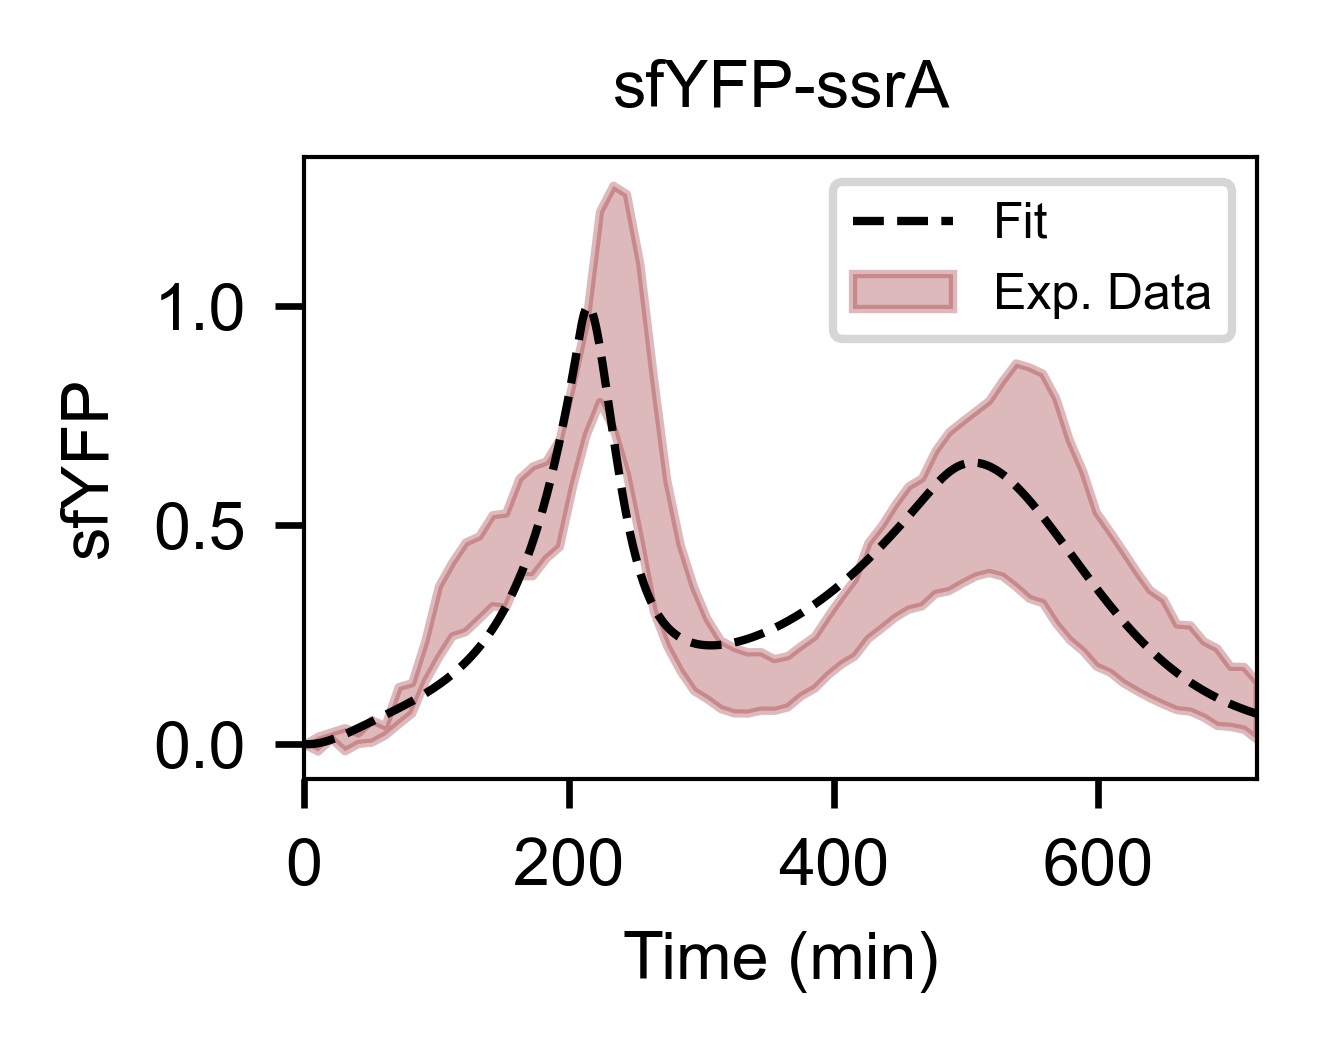

In [10]:
# Image for paper

# Style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'legend.fontsize': 6
})
tick_fontsize = 8

fig_size = 2.3,1.8

lwd = 1 # linewdith for plot
alpha_fill = 0.3 # alpha value for filling the std region

# ===============================
# Compute means, stds, and bounds
# ===============================
min_length = min(len(A_non_leaky[0]), len(A_non_leaky[1]), len(A_non_leaky[2]))
A_non_leaky[0], A_non_leaky[1], A_non_leaky[2] = A_non_leaky[0][:min_length], A_non_leaky[1][:min_length], A_non_leaky[2][:min_length]
mean_exp_A = np.mean(A_non_leaky, axis=0)[:,0]/A_max
std_exp_A  = np.std(A_non_leaky, axis=0)[:,0]/A_max
upper_A, lower_A = mean_exp_A + std_exp_A, mean_exp_A - std_exp_A


fig, ax = plt.subplots(figsize=fig_size , dpi = 300)

# Model simulations 
ax.plot(
    timepoints[:tf_I],
    sol_deg['protein_sfYFP'][:tf_I] / np.max(sol_deg['protein_sfYFP']),
    '--', label="Fit", color='black', linewidth=lwd
)
ax.fill_between(
    time_A[0][:tf_i], upper_A[:tf_i], lower_A[:tf_i],
    color='#931a20', alpha=alpha_fill, label='Exp. Data'
)


# Labels and axis limits
ax.set_xlabel('Time (min)')
ax.set_ylabel('sfYFP')
ax.set_title('sfYFP-ssrA')
ax.set_xlim(0, 720)
ax.set_xticks([0, 200, 400, 600])
ax.legend(loc='upper right')


# Spine control
spine_width = 0.5
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(spine_width)

# Ticks
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

# Layout and save
plt.tight_layout()
plt.savefig('figures/sfYFP_ssrA.svg', format='svg', dpi=300, bbox_inches='tight', transparent=True)

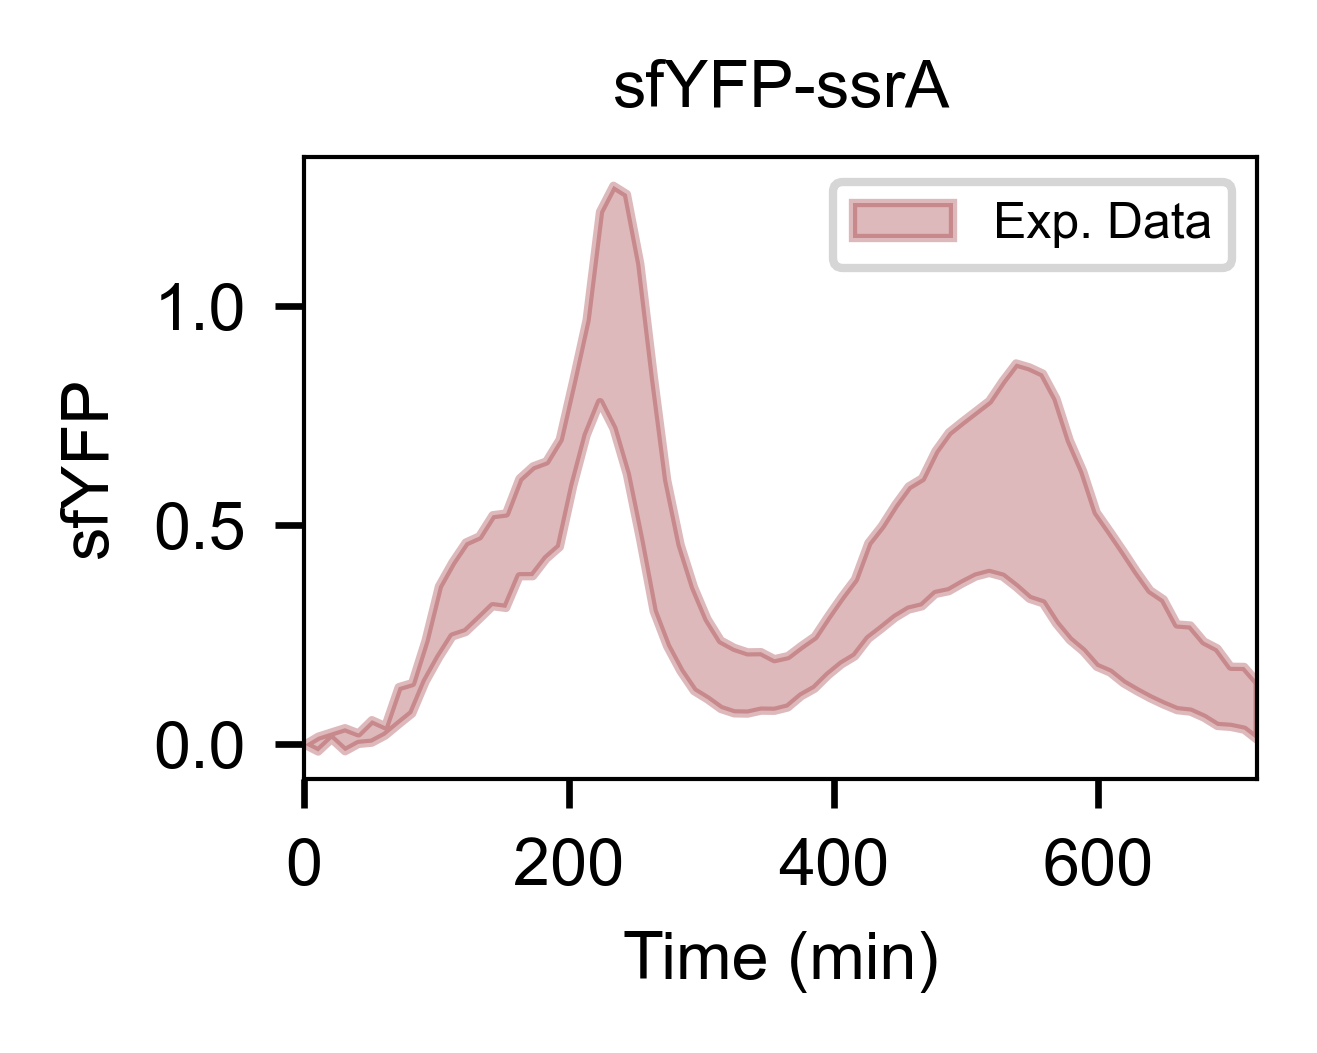

In [11]:
# Image for paper

# Style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'legend.fontsize': 6
})
tick_fontsize = 8

fig_size = 2.3,1.8

lwd = 1 # linewdith for plot
alpha_fill = 0.3 # alpha value for filling the std region

# ===============================
# Compute means, stds, and bounds
# ===============================
min_length = min(len(A_non_leaky[0]), len(A_non_leaky[1]), len(A_non_leaky[2]))
A_non_leaky[0], A_non_leaky[1], A_non_leaky[2] = A_non_leaky[0][:min_length], A_non_leaky[1][:min_length], A_non_leaky[2][:min_length]
mean_exp_A = np.mean(A_non_leaky, axis=0)[:,0]/A_max
std_exp_A  = np.std(A_non_leaky, axis=0)[:,0]/A_max
upper_A, lower_A = mean_exp_A + std_exp_A, mean_exp_A - std_exp_A


fig, ax = plt.subplots(figsize=fig_size , dpi = 300)

# # Model simulations 

# ax.plot(
#     timepoints[:tf_I],
#     sol_deg['protein_sfYFP'][:tf_I] / np.max(sol_deg['protein_sfYFP']),
#     '--', label="Fit", color='black', linewidth=lwd
# )
ax.fill_between(
    time_A[0][:tf_i], upper_A[:tf_i], lower_A[:tf_i],
    color='#931a20', alpha=alpha_fill, label='Exp. Data'
)


# Labels and axis limits
ax.set_xlabel('Time (min)')
ax.set_ylabel('sfYFP')
ax.set_title('sfYFP-ssrA')
ax.set_xlim(0, 720)
ax.set_xticks([0, 200, 400, 600])
ax.legend(loc='upper right')


# Spine control
spine_width = 0.5
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(spine_width)

# Ticks
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

# Layout and save
plt.tight_layout()
plt.savefig('figures/sfYFP_ssrA_exp.svg', format='svg', dpi=300, bbox_inches='tight', transparent=True)

In [12]:
# ## To export the scaled model prediction along with scaled experimental data

# GEAGS_model = dict()
# GEAGS_exp = dict()

# # Deg-tagged protein prediction 

# GEAGS_model['Scaled_deg_tag_protein'] = sol_deg['protein_sfYFP'][:tf_I]/np.max(sol_deg['protein_sfYFP'])
# GEAGS_exp['A1'] = A_non_leaky[0][:tf_i].reshape(-1)/A_max
# GEAGS_exp['A2'] = A_non_leaky[1][:tf_i].reshape(-1)/A_max
# GEAGS_exp['A3'] = A_non_leaky[2][:tf_i].reshape(-1)/A_max

# # Non Deg-tagged protein prediction 

# GEAGS_model['Scaled_no_deg_tag_protein'] = sol_no_deg['protein_sfYFP'][:tf_I]/np.max(sol_deg['protein_sfYFP'])
# GEAGS_exp['B1'] = B_non_leaky[0][:tf_i].reshape(-1)/A_max
# GEAGS_exp['B2'] = B_non_leaky[1][:tf_i].reshape(-1)/A_max
# GEAGS_exp['B3'] = B_non_leaky[2][:tf_i].reshape(-1)/A_max

# GEAGS_model['Time_model'] = timepoints[:tf_I]
# GEAGS_exp['Time_exp'] = time_A[0][:tf_i].reshape(-1)


# GEAGS_model_df = pd.DataFrame(data = GEAGS_model)
# GEAGS_model_df.to_csv('simulation_scaled_data.csv')

# GEAGS_exp_df = pd.DataFrame(data = GEAGS_exp)
# GEAGS_exp_df.to_csv('expt_scaled_data.csv')


In [13]:
# Print the fold change between protein from the model comparison
# np.max(sol_no_deg['protein_sfYFP'])/np.max(sol_deg['protein_sfYFP'])

In [14]:
## Command to export the complete simulation run data

# sol_deg_run_data = pd.DataFrame(sol_deg)
# sol_deg_run_data.to_csv('GEAGS_sol_deg_run_data_062724.csv')

# sol_no_deg_run_data = pd.DataFrame(sol_no_deg)
# sol_no_deg_run_data.to_csv('GEAGS_sol_no_deg_run_data_062724.csv')

In [15]:
## Plotting the values of parameters in the model 
param_dict_biocrnpyler = model_degtag.get_parameter_dictionary()
list(param_dict_biocrnpyler.keys())

['k_tx_1b__bacterial_transcription',
 'k_tx_1u__bacterial_transcription',
 'RNAP_max__bacterial_transcription',
 'n_gamma_RNAP__bacterial_transcription',
 'c_max__logistic_cell_growth',
 'k_tx_2b__bacterial_transcription',
 'k_tx_2u__bacterial_transcription',
 'b_tx_4u__mrna_degradation',
 'n_delta__bacterial_transcription',
 'k_tx_3__bacterial_transcription',
 'k_tl_1b__bacterial_translation',
 'k_tl_1u__bacterial_translation',
 'Et_max__bacterial_translation',
 'n_gamma_Et__bacterial_translation',
 'k_tl_2b__bacterial_translation',
 'k_tl_2u__bacterial_translation',
 'tRNA_max__bacterial_translation',
 'n_gamma_tRNA__bacterial_translation',
 'k_tl_3b__bacterial_translation',
 'k_tl_3u__bacterial_translation',
 'Ribo_max__bacterial_translation',
 'n_gamma_Ribo__bacterial_translation',
 'k_tl_4__bacterial_translation',
 'k_tl_5__bacterial_translation',
 'b_tl_5__bacterial_translation',
 'n_gamma_folding__bacterial_translation',
 'k_tl_8__bacterial_translation',
 'n_gamma_syn__bacterial

In [16]:
## Plotting the names of species in the model 
model_degtag.get_species_dictionary()

{'dna_sfYFP': 100.0,
 'protein_sigma_machinery': 135.0,
 'protein_holoenzyme_machinery': 0.0,
 'protein_NT_nucleotide': 942.0,
 'rna_T_sfYFP': 0.0,
 'complex_dna_sfYFP_protein_holoenzyme_machinery_': 0.0,
 'protein_AA_aminoacid': 85610.0,
 'protein_sfYFP': 0.0,
 'protein_unfolded_protein_degtag': 0.0,
 'protein_peptide_chain_peptide': 0.0,
 'protein_Ct_machinery': 0.0,
 'protein_Caa_machinery': 0.0,
 'protein_Ctic_machinery': 0.0,
 'protein_C_deg_unfolded_machinery': 0.0,
 'protein_C_deg_folded_machinery': 0.0,
 'protein_RNAase_machinery': 90.0,
 'cell_count_count': 11500000.000000002,
 'complex_dna_sfYFP_protein_holoenzyme_machinery_open_': 0.0,
 'complex_protein_RNAase_machinery_rna_T_sfYFP_': 0.0}

In [17]:
## Export the parameter values 

param_dict = params.valuesdict()
# param_dict_guess_df = dict()
# param_dict_guess_df['Param name'] = param_dict.keys()
# param_dict_guess_df['Param'] = param_dict.values()
# param_data = pd.DataFrame(data = param_dict_guess_df)
# param_data.to_csv('model_param_file_030525.csv')
param_dict

{'n_gamma_RNAP': 0.23,
 'n_gamma_Et': 0.37,
 'n_gamma_tRNA': 0.6,
 'n_gamma_Ribo': 0.67,
 'n_gamma_Protease': 0.4523759879786752,
 'Sigma_IC': 135.0,
 'NT_IC': 942.0,
 'RNAase_IC': 90.0,
 'AA_IC': 85610.0,
 'Ribo_max': 280.0,
 'tRNA_max': 1535.0,
 'RNAP_max': 1960.0,
 'Et_max': 1090.0,
 'Protease_max': 6146.866936691339,
 'k_tx_1b': 0.05061,
 'k_tx_1u': 14.081,
 'k_tx_2b': 0.0019382,
 'k_tx_2u': 0.09999,
 'k_tx_3': 0.003597,
 'k_tx_4b': 2.54926,
 'k_tx_4u': 161.36218,
 'k_tx_5': 0.42521,
 'k_tl_1b': 0.002793,
 'k_tl_1u': 11.48224,
 'k_tl_2u': 35.1135,
 'k_tl_2b': 8.24109,
 'k_tl_3b': 0.04287,
 'k_tl_3u': 12.3438,
 'k_tl_4': 0.17,
 'k_tl_5': 0.10047,
 'b_tl_5': 0.5007,
 'k_tl_6': 0.0483677729298024,
 'k_tl_7': 0.0008,
 'k_tl_8': 138.0,
 'k_tl_9b_P': 0.000454,
 'k_tl_9b_Pm': 0.2033128764912187,
 'k_tl_9u': 44.19785628188373,
 'k_tl_10': 0.0001,
 'n_gamma_folding': 0.26,
 'n_gamma_syn': 0.296,
 'C_max': 501250000.0,
 'C_0': 6666666.67,
 'k_gr': 0.015486612375000002}